In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from diffdrr.data import load_example_ct
from diffdrr.drr import DRR
from diffdrr.visualization import plot_drr
import torch
import numpy as np
import pyvista as pv
from scipy.spatial.transform import Rotation
import matplotlib
matplotlib.use("Agg")  # Non-GUI backend
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from PIL import Image
import tifffile



from diffdrr.drr import DRR
from diffdrr.data import read
from diffdrr.visualization import visualize_scene, plot_drr
from diffdrr.pose import RigidTransform

sns.set_context("talk")

In [42]:
import matplotlib.pyplot as plt
import torch

from diffdrr.drr import DRR
from diffdrr.data import load_example_ct
from diffdrr.visualization import plot_drr

# Read in the volume and get its origin and spacing in world coordinates
subject = load_example_ct()

# Initialize the DRR module for generating synthetic X-rays
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
drr = DRR(
    subject,     # An object storing the CT volume, origin, and voxel spacing
    sdd=1020.0,  # Source-to-detector distance (i.e., focal length)
    height=200,  # Image height (if width is not provided, the generated DRR is square)
    delx=2.0,    # Pixel spacing (in mm)
).to(device)

# Set the camera pose with rotations (yaw, pitch, roll) and translations (x, y, z)
rotations = torch.tensor([[0.0, 0.0, 0.0]], device=device)
translations = torch.tensor([[0.0, 850.0, 0.0]], device=device)

# 📸 Also note that DiffDRR can take many representations of SO(3) 📸
# For example, quaternions, rotation matrix, axis-angle, etc...
img = drr(rotations, translations, parameterization="euler_angles", convention="ZXY")
plot_drr(img, ticks=False)
plt.show()

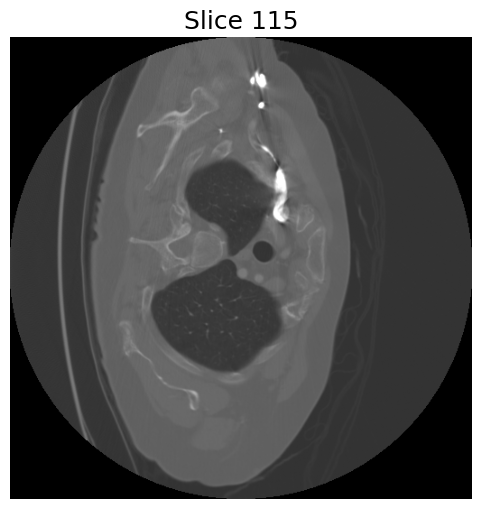

In [16]:
import torchio as tio
import matplotlib.pyplot as plt

# 1) Get the ScalarImage object
img_obj = subject['volume']  # a tio.ScalarImage

# 2) Extract its tensor (shape [1, 512, 512, 133])
vol_tensor = img_obj.data  

# 3) Remove the channel dimension
scalar_image = vol_tensor.squeeze(0)  # now (512, 512, 133)

# 4) Pick a slice
slice_index = 115
slice_img = scalar_image[:, :, slice_index]

# 5) Plot
plt.figure(figsize=(6,6))
plt.imshow(slice_img.cpu().numpy(), cmap='gray', aspect='equal')
plt.title(f"Slice {slice_index}")
plt.axis('off')
plt.show()


In [45]:
# Read in the volume and get its origin and spacing in world coordinates
subject = load_example_ct(bone_attenuation_multiplier=1.0)

# Initialize the DRR module for generating synthetic X-rays
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
drr = DRR(
    subject,  # A torchio.Subject object storing the CT volume, origin, and voxel spacing
    sdd=1020,  # Source-to-detector distance (i.e., the C-arm's focal length)
    height=200,  # Height of the DRR (if width is not seperately provided, the generated image is square)
    delx=2.0,  # Pixel spacing (in mm)
).to(device)

# Specify the C-arm pose with a rotation (yaw, pitch, roll) and orientation (x, y, z)
rot = torch.tensor([[0.0, 0.0, 0.0]], device=device)
xyz = torch.tensor([[0.0, 650.0, 0.0]], device=device)
img = drr(rot, xyz, parameterization="euler_angles", convention="ZXY")
plot_drr(img, ticks=False)
plt.show()

In [12]:
subject.reorient

tensor([[ 1.,  0.,  0.,  0.],
        [ 0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  1.]])

In [31]:
import nibabel as nib
import torch
import torchio as tio

# 1) Load your .nii.gz
nii_path = '/home/sampath/VertebralDiffusion/notebooks/rotated_test_both1.nii.gz'
nib_obj = nib.load(nii_path)
vol_np  = nib_obj.get_fdata()                     # e.g. shape (X, Y, Z)

# 2) To PyTorch, add a channel dim (C=1)
vol_t = torch.from_numpy(vol_np.astype('float32')) # dtype float32
#stack_vol = torch.stack([vol_t, vol_t], dim=0)  # shape (2, 1, X, Y, Z)
vol_t = vol_t.unsqueeze(0)     
#print(vol_t.shape)                   # shape (1, X, Y, Z)

# 3) Wrap in a ScalarImage (so DiffDRR sees your affine too)
scalar_img = tio.ScalarImage(tensor=vol_t)

# Now you can build your Subject:
subject = tio.Subject(volume=scalar_img)
print(subject)  # should list 'volume' among its images


Subject(Keys: ('volume',); images: 1)


In [52]:
stack_vol.shape

torch.Size([2, 88, 88, 120])

In [23]:
subject['volume']

ScalarImage(shape: (2, 88, 88, 120); spacing: (1.00, 1.00, 1.00); orientation: RAS+; dtype: torch.FloatTensor; memory: 7.1 MiB)

In [32]:
subjects = read(subject['volume'])

Loading CT volume from '400000.nii'...
Saved volume slices as 'slices.png'
DRR before normalization: min = 0.0 max = 29.854000091552734


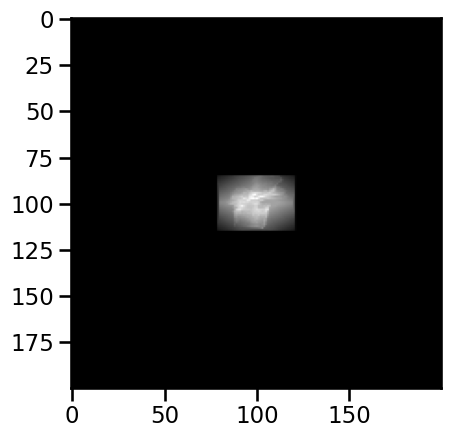

In [24]:

# ----------------------------------------
# Step 1: Set device and read volume
# ----------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Loading CT volume from '400000.nii'...")
#subjects = read("/mnt/oracle_data/killeen/NMDID-ARCADE/nifti/case-100012/TORSO/THIN_BONE_TORSO_STANDARD_TORSO_Thorax_115113_12.nii.gz")
subjects = read("/home/sampath/VertebralDiffusion/notebooks/rotated_test_both1.nii.gz")
volume_image = subjects.get_first_image()
volume = volume_image.data


# ----------------------------------------
# Step 2: Scale volume intensities
# ----------------------------------------
#scaling_factor = 500.0
#scaled_volume = scaling_factor * volume
#volume_image.set_data(scaled_volume)

# ----------------------------------------
# Step 3: Save central slices for inspection
# ----------------------------------------
vol_np = volume.squeeze(0).cpu().numpy()
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(vol_np[vol_np.shape[0] // 2], cmap='gray')
plt.title("Axial Slice")
plt.subplot(1, 3, 2)
plt.imshow(vol_np[:, vol_np.shape[1] // 2, :], cmap='gray')
plt.title("Coronal Slice")
plt.subplot(1, 3, 3)
plt.imshow(vol_np[:, :, vol_np.shape[2] // 2], cmap='gray')
plt.title("Sagittal Slice")
plt.tight_layout()
plt.savefig("slices.png")
plt.close()
print("Saved volume slices as 'slices.png'")

# ----------------------------------------
# Step 4: Create DRR generator
# ----------------------------------------
drr = DRR(
    subjects,
    sdd=1020,
    height=200,
    delx=2.0,
).to(device)

# ----------------------------------------
# Step 5: Generate DRR
# ----------------------------------------
rotations = torch.tensor([[0.0, 0.0, 0.0]], dtype=torch.float32, device=device)
translations = torch.tensor([[0.0, 1050.0, 0.0]], dtype=torch.float32, device=device)
img = drr(rotations, translations, parameterization="euler_angles", convention="ZXY")
print("DRR before normalization: min =", float(img.min()), "max =", float(img.max()))
plt.imshow(img.cpu().numpy()[0, 0, :, :], cmap='gray')
plt.show()

# Construct transformation matrix for PyVista scene
#euler_angles = np.array([0.0, 0.0, 0.0])
#translation_np = np.array([0.0, 850.0, 0.0])
#R_mat = Rotation.from_euler('zxy', euler_angles, degrees=False).as_matrix()
#T = np.eye(4)
#T[:3, :3] = R_mat
#T[:3, 3] = translation_np
#pose = RigidTransform(torch.from_numpy(T).float().unsqueeze(0).to(device))

#pl = visualize_scene(drr, pose, labelmap=False, grid=True, threshold=20)
#pl.show(screenshot="scene_output.png")
#print("Scene screenshot saved as 'scene_output.png'")


DRR before normalization: min = 3.47334623336792 max = 32.49995422363281


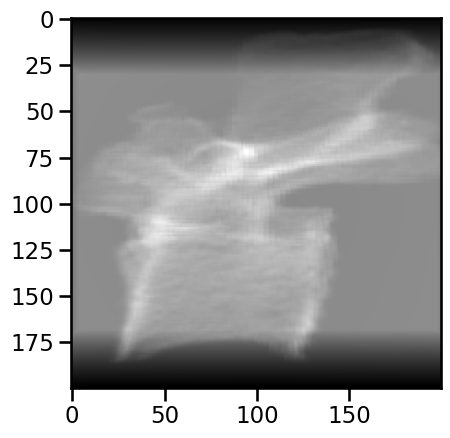

In [32]:
rotations = torch.tensor([[0.0, 0.0, 0.0]], dtype=torch.float32, device=device)
translations = torch.tensor([[0.0, 180.0, 0.0]], dtype=torch.float32, device=device)
img = drr(rotations, translations, parameterization="euler_angles", convention="ZXY")
print("DRR before normalization: min =", float(img.min()), "max =", float(img.max()))
plt.imshow(img.cpu().numpy()[0, 0, :, :], cmap='gray')
plt.show()

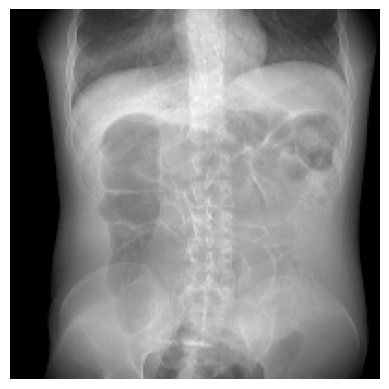

In [3]:
# In a Jupyter / IPython notebook cell
%matplotlib inline

import matplotlib.pyplot as plt

plt.imshow(img[0, 0].cpu().numpy(), cmap='gray')
plt.axis("off")             # optional: hide axes
plt.show()


In [40]:
from diffdrr.pose import convert


class Reconstruction(torch.nn.Module):
    def __init__(self, subject, device):
        super().__init__()
        self.drr = DRR(subject, sdd=1020.0, height=200, delx=2.0).to(device=device)

        # Replace the known density with an initial estimate
        self.density = torch.nn.Parameter(
            torch.zeros(*subject.volume.spatial_shape, device=device)
        )

    def forward(self, pose, **kwargs):
        source, target = self.drr.detector(pose, None)
        img = self.drr.render(self.density, source, target)
        return self.drr.reshape_transform(img, batch_size=len(pose))

In [46]:
gt = img

In [48]:
from tqdm import tqdm
recon = Reconstruction(subject, device)
optimizer = torch.optim.Adam(recon.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

rot = torch.tensor([[0.0, 0.0, 0.0]], device=device)
xyz = torch.tensor([[0.0, 850.0, 0.0]], device=device)
pose = convert(rot, xyz, parameterization="euler_angles", convention="ZXY")

losses = []
for itr in tqdm(range(101), ncols=100):
    optimizer.zero_grad()
    est = recon(pose)
    loss = criterion(est, gt)
    print(loss)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if itr % 25 == 0:
        plot_drr(
            torch.concat([est, gt, est - gt]),
            title=["Reconstruction", "Ground Truth", "Difference"],
        )
        plt.show()

plt.plot(losses)
plt.xlabel("# Iterations")
plt.ylabel("MSE")
plt.yscale("log")
plt.show()

  2%|█▏                                                             | 2/101 [00:00<00:05, 17.55it/s]

tensor(1291.6927, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(1268.6743, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(1245.8995, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(1223.3728, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(1201.0977, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(1179.0780, device='cuda:0', grad_fn=<MseLossBackward0>)


 10%|██████▏                                                       | 10/101 [00:00<00:03, 29.32it/s]

tensor(1157.3174, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(1135.8190, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(1114.5862, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(1093.6218, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(1072.9286, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(1052.5088, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(1032.3647, device='cuda:0', grad_fn=<MseLossBackward0>)


 18%|███████████                                                   | 18/101 [00:00<00:02, 31.37it/s]

...

 93%|█████████████████████████████████████████████████████████▋    | 94/101 [00:03<00:00, 31.73it/s]

tensor(204.3364, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(199.6695, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(195.1028, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(190.6343, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(186.2622, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(181.9846, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(177.7996, device='cuda:0', grad_fn=<MseLossBackward0>)


 97%|████████████████████████████████████████████████████████████▏ | 98/101 [00:03<00:00, 31.99it/s]

tensor(173.7055, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(169.7005, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(165.7829, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(161.9508, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(158.2027, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(154.5369, device='cuda:0', grad_fn=<MseLossBackward0>)
tensor(150.9518, device='cuda:0', grad_fn=<MseLossBackward0>)


100%|█████████████████████████████████████████████████████████████| 101/101 [00:03<00:00, 30.41it/s]


In [33]:
plt.imshow(img[0, 0, :, :].cpu().numpy())
plt.show()

In [34]:
drr_raw = img[0,0].cpu().detach().numpy()   # shape (H, W)

# 1) exponentiate to get transmitted intensity I/I0 = exp(−∫µ dx)
drr_int = np.exp(-drr_raw)

# 2) normalize into [0,1]
drr_norm = (drr_int - drr_int.min()) / (drr_int.max() - drr_int.min())

# 3) display with a gray colormap
plt.imshow(drr_norm, cmap='gray', interpolation='nearest')
plt.axis('off')
plt.show()